# 05 — Business Case: A Digital Twin of a District-Heating Pipe

Time to put it all together on a scenario an energy company actually faces. A **district-heating** operator
pumps hot water from a plant through a long buried pipe to deliver heat to a neighbourhood. Along the way the
water **flows** (advection), **conducts** heat along itself (diffusion), and **loses heat to the surrounding
ground** (the thing that costs money). Two questions the business cares about:

1. **Forward / operations:** given the inlet temperature and flow, *what temperature arrives at the customers*,
   and how does the pipe warm up after a cold start?
2. **Inverse / monitoring:** the pipe is buried and we only have a few sensors. *How much heat are we losing,
   and is the insulation degrading?* The heat-loss coefficient is a KPI we cannot measure directly.

We answer both with PINNs, reusing every idea from notebooks 01–04, and we keep a **classical finite-difference
solver** alongside as a reality check.

## 1. The governing equation and what each term buys us

The water temperature $u(x,t)$ along the pipe obeys an **advection–diffusion–reaction** equation:

$$\underbrace{\frac{\partial u}{\partial t}}_{\text{change in time}}
+ \underbrace{v\,\frac{\partial u}{\partial x}}_{\text{advection: flow carries heat downstream}}
= \underbrace{\alpha\,\frac{\partial^2 u}{\partial x^2}}_{\text{diffusion along the pipe}}
- \underbrace{\beta\,(u - u_\text{env})}_{\text{heat loss to the ground}}$$

```
   plant                          buried pipe, flow speed v  ───►                         customers
   x=0  ┌───────────────────────────────────────────────────────────────────────────┐  x=L
 T_in ─►│  ~~~ hot water ~~~►   ~~~►   ~~~►   ~~~►   ~~~►   ~~~►   ~~~►   ~~~►          │─►  T_out(t)
        └───────────────────────────────────────────────────────────────────────────┘
              │      │      │      │      │      │      │      │      │      │
              ▼      ▼      ▼      ▼      ▼      ▼      ▼      ▼      ▼      ▼   heat leaking to ground
        ==============  surrounding ground at temperature u_env  ========================
```

- $v$ — **flow velocity**: bigger flow pushes hot water further before it cools.
- $\alpha$ — **diffusion**: small in a flowing pipe; smooths sharp temperature fronts.
- $\beta$ — **heat-loss coefficient**: the star of the show. High $\beta$ = poor/wet insulation = expensive
  losses. This is what we will *monitor*.
- $u_\text{env}$ — ground temperature.

**Conditions:** the pipe starts cold ($u=u_\text{env}$); the plant ramps the inlet up to $T_\text{in}$; at the
far end heat simply flows out ($\partial u/\partial x=0$, a standard *outflow* condition).

## 2. A practical PINN habit: work in normalized variables

Temperatures here run from ~10 °C to ~90 °C. Neural networks train far better when inputs and outputs are
**O(1)**, so we define a dimensionless temperature

$$\theta = \frac{u - u_\text{env}}{T_\text{in} - u_\text{env}} \in [0, 1],$$

$\theta=0$ means "as cold as the ground", $\theta=1$ means "as hot as the inlet". Substituting, $\theta$ obeys
the *same-shaped* equation:

$$\theta_t + v\,\theta_x = \alpha\,\theta_{xx} - \beta\,\theta,$$

with a smooth plant start-up $\theta(0,t)=1-e^{-t/\tau}$, cold start $\theta(x,0)=0$, and outflow
$\theta_x(L,t)=0$. We solve for $\theta$ and convert back to °C at the end. **Normalizing like this is one of the
most useful, least-glamorous PINN tricks.**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cpu")

# --- physical setup (scaled units: x in [0,1] along the pipe, t in [0,1.5] of a warm-up window) ---
v      = 1.0     # flow velocity
alpha  = 0.02    # along-pipe diffusion (small)
beta   = 2.0     # heat-loss coefficient (the KPI)
tau    = 0.05    # plant start-up time constant
L, T   = 1.0, 1.5

u_env  = 10.0    # ground temperature [C]
T_in   = 90.0    # inlet temperature  [C]

def to_celsius(theta):
    return u_env + (T_in - u_env)*theta

print(f"decay length v/beta = {v/beta:.2f}  ->  at the outlet theta ~ exp(-beta/v) = {np.exp(-beta/v):.3f}")
print(f"so steady delivery temp ~ {to_celsius(np.exp(-beta/v)):.1f} C")

decay length v/beta = 0.50  ->  at the outlet theta ~ exp(-beta/v) = 0.135
so steady delivery temp ~ 20.8 C


## 3. A classical baseline for the steady state (so we can trust the PINN)

Before training anything, let's compute the **steady-state** profile the pipe should settle into, using a plain
finite-difference solver (the classical approach). Steady state means $\theta_t=0$:

$$v\,\theta_x - \alpha\,\theta_{xx} + \beta\,\theta = 0,\quad \theta(0)=1,\ \theta_x(L)=0.$$

We discretise the pipe into points, write central differences, and solve the resulting linear system. This is
our "ground truth" for late times — and a reminder that for simple forward problems, classical solvers are
cheap and excellent.

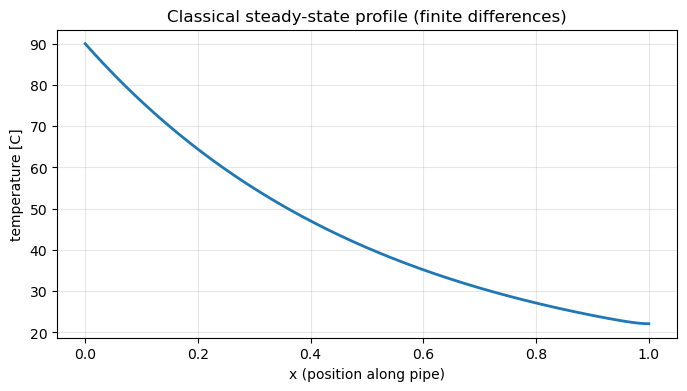

steady delivery temperature at outlet: 22.1 C


In [2]:
def steady_state_fd(vv, aa, bb, N=400):
    x = np.linspace(0, L, N); h = x[1]-x[0]
    A = np.zeros((N, N)); rhs = np.zeros(N)
    # inlet Dirichlet
    A[0,0] = 1.0; rhs[0] = 1.0
    for i in range(1, N-1):
        A[i, i-1] = -aa/h**2 - vv/(2*h)
        A[i, i  ] =  2*aa/h**2 + bb
        A[i, i+1] = -aa/h**2 + vv/(2*h)
    # outflow Neumann theta'(L)=0  ->  theta[N-1]=theta[N-2]
    A[N-1, N-1] = 1.0; A[N-1, N-2] = -1.0; rhs[N-1] = 0.0
    theta = np.linalg.solve(A, rhs)
    return x, theta

x_ss, theta_ss = steady_state_fd(v, alpha, beta)
plt.figure(figsize=(8,4))
plt.plot(x_ss, to_celsius(theta_ss), lw=2)
plt.xlabel("x (position along pipe)"); plt.ylabel("temperature [C]")
plt.title("Classical steady-state profile (finite differences)"); plt.grid(alpha=0.3); plt.show()
print("steady delivery temperature at outlet:", round(to_celsius(theta_ss[-1]),1), "C")

## 4. Forward PINN — the pipe warming up after a cold start

Now the transient PINN. Same recipe as notebook 03, with the richer residual and an **outflow** boundary
(a derivative condition instead of a fixed value — new, but easy: we just penalise $\theta_x(L,t)$).

In [3]:
class MLP(nn.Module):
    def __init__(self, hidden=32, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(n_hidden_layers-1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = MLP().to(device)

def residual(x, t):
    x = x.requires_grad_(True); t = t.requires_grad_(True)
    th = model(x, t)
    th_t  = torch.autograd.grad(th,  t, torch.ones_like(th),  create_graph=True)[0]
    th_x  = torch.autograd.grad(th,  x, torch.ones_like(th),  create_graph=True)[0]
    th_xx = torch.autograd.grad(th_x, x, torch.ones_like(th_x), create_graph=True)[0]
    return th_t + v*th_x - alpha*th_xx + beta*th

# point sets
N_f = 1600
x_f = torch.rand(N_f,1, device=device)*L
t_f = torch.rand(N_f,1, device=device)*T

N_b = 300
t_in  = torch.rand(N_b,1, device=device)*T          # inlet x=0
x_in  = torch.zeros(N_b,1, device=device)
t_out = torch.rand(N_b,1, device=device)*T          # outlet x=L
x_out = (torch.ones(N_b,1, device=device)*L)

N_ic = 300
x_ic = torch.rand(N_ic,1, device=device)*L
t_ic = torch.zeros(N_ic,1, device=device)

def inlet_ramp(t):
    return 1.0 - torch.exp(-t/tau)                  # smooth plant start-up

iter     0 | loss 2.721e+01 | pde 5.95e-02 | ic 3.66e-02 | inlet 1.32e+00 | outflow 1.18e-03


iter  1000 | loss 3.465e-02 | pde 1.83e-02 | ic 5.27e-04 | inlet 2.25e-04 | outflow 6.56e-05


iter  2000 | loss 1.409e-02 | pde 9.97e-03 | ic 1.50e-04 | inlet 4.21e-05 | outflow 1.37e-05


iter  3000 | loss 1.002e-02 | pde 7.31e-03 | ic 1.02e-04 | inlet 2.59e-05 | outflow 8.10e-06


iter  4000 | loss 9.831e-03 | pde 5.87e-03 | ic 7.02e-05 | inlet 6.07e-05 | outflow 6.72e-05


iter  5000 | loss 6.437e-03 | pde 4.79e-03 | ic 6.32e-05 | inlet 1.55e-05 | outflow 3.56e-06


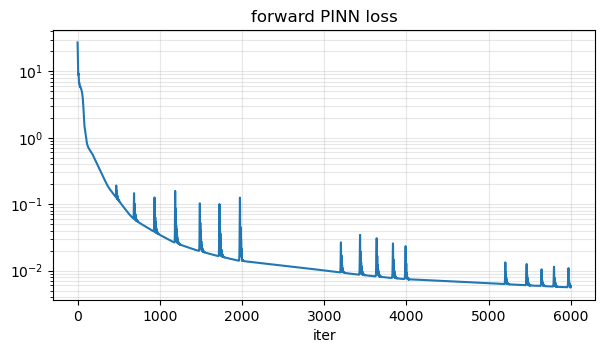

In [4]:
w_ic, w_bc = 20.0, 20.0

def outflow_grad(x, t):
    x = x.requires_grad_(True)
    th = model(x, t)
    th_x = torch.autograd.grad(th, x, torch.ones_like(th), create_graph=True)[0]
    return th_x

def compute_loss():
    loss_pde = torch.mean(residual(x_f, t_f)**2)
    loss_ic  = torch.mean(model(x_ic, t_ic)**2)                          # theta(x,0)=0
    loss_in  = torch.mean((model(x_in, t_in) - inlet_ramp(t_in))**2)     # inlet ramp
    loss_out = torch.mean(outflow_grad(x_out, t_out)**2)                 # theta_x(L,t)=0
    loss = loss_pde + w_ic*loss_ic + w_bc*(loss_in + loss_out)
    return loss, loss_pde, loss_ic, loss_in, loss_out

optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

history = []
for it in range(6000):                    # ~2-3 min on CPU
    optimizer.zero_grad()
    loss, lp, lic, lin, lout = compute_loss()
    loss.backward(); optimizer.step(); scheduler.step()
    history.append(loss.item())
    if it % 1000 == 0:
        print(f"iter {it:5d} | loss {loss.item():.3e} | pde {lp.item():.2e} | ic {lic.item():.2e} | inlet {lin.item():.2e} | outflow {lout.item():.2e}")
plt.figure(figsize=(7,3.5)); plt.semilogy(history); plt.title("forward PINN loss"); plt.xlabel("iter"); plt.grid(True, which="both", alpha=0.3); plt.show()

### 4a. Watch the thermal front travel down the pipe

We plot the temperature along the pipe at several times. Early on only the near end is hot; the warm front
sweeps toward the customers at roughly the flow speed $v$, then the profile **settles onto the classical
steady-state curve** (dashed black) — a strong validation that the PINN learned the right physics.

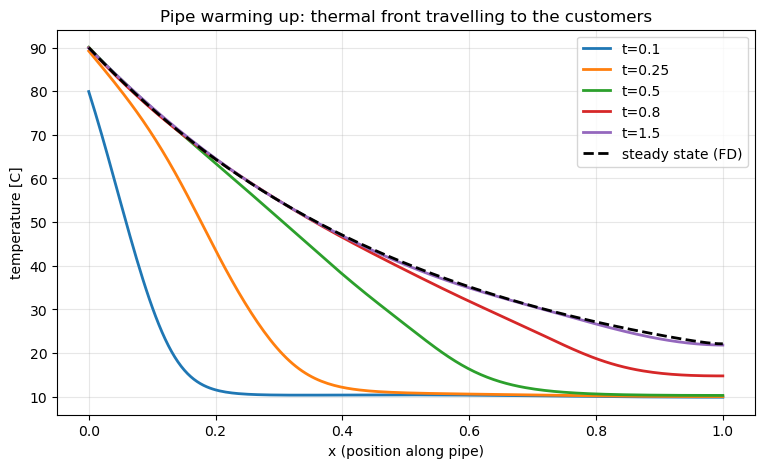

In [ ]:
plt.figure(figsize=(9,5))
xline = torch.linspace(0, L, 200, device=device).reshape(-1,1)
for t_snap in [0.1, 0.25, 0.5, 0.8, 1.5]:
    tline = torch.full_like(xline, t_snap)
    with torch.no_grad():
        th = model(xline, tline).cpu().numpy().flatten()
    plt.plot(xline.cpu().numpy().flatten(), to_celsius(th), lw=2, label=f"t={t_snap}")
plt.plot(x_ss, to_celsius(theta_ss), "k--", lw=2, label="steady state (FD)")
plt.xlabel("x (position along pipe)"); plt.ylabel("temperature [C]")
plt.title("Pipe warming up: thermal front travelling to the customers")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# we can observe that the PINN solution converges to the classical steady-state solution as time progresses, demonstrating the model's ability to capture 
# the dynamics of the system accurately.
# the reason it converges to a steady solution is that the inlet temperature remains constant at 90C after the initial ramp-up after 0.5secs (tau=0.05), 

### 4b. Solve the steady state *directly* with its own PINN — a three-way check

Above we compared the **transient** PINN's settled profile against the **classical FD** steady solution. But we
can also attack the steady state **directly with a PINN**: just drop the time derivative and solve

$$v\,\theta_x = \alpha\,\theta_{xx} - \beta\,\theta,\qquad \theta(0)=1,\ \ \theta_x(L)=0.$$

Now there is **no time at all**, so the network takes a **single input** $x$ — it is a *curve*, not a surface.
That makes it much cheaper than the transient PINN (fewer derivatives, one dimension less).

This gives us **three independent routes to the same answer**, which is exactly the kind of cross-check you want
before trusting a model:

| Route | What it is |
|---|---|
| transient PINN at large $t$ | the time-dependent PINN, left to settle |
| **steady PINN** (new) | a PINN solving the steady equation directly |
| classical FD | the trusted numerical baseline |

If all three land on top of each other, the physics is right and the PINNs are trained properly.

In [6]:
class SteadyPINN(nn.Module):
    # steady state has no time -> a single input x
    def __init__(self, hidden=32, n_hidden_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(n_hidden_layers-1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def steady_derivs(net, x):
    # returns theta, theta_x, theta_xx
    x = x.requires_grad_(True)
    th    = net(x)
    th_x  = torch.autograd.grad(th,  x, torch.ones_like(th),  create_graph=True)[0]
    th_xx = torch.autograd.grad(th_x, x, torch.ones_like(th_x), create_graph=True)[0]
    return th, th_x, th_xx

model_s = SteadyPINN().to(device)
opt_s   = torch.optim.Adam(model_s.parameters(), lr=3e-3)

xf_s = torch.rand(1500,1, device=device)*L
x0_s = torch.zeros(1,1, device=device)          # inlet
xL_s = torch.ones(1,1, device=device)*L         # outlet

for it in range(4000):                          # ~1 min: steady is much cheaper than transient
    opt_s.zero_grad()
    _, th_x, th_xx = steady_derivs(model_s, xf_s)
    th = model_s(xf_s)
    loss_pde = torch.mean((v*th_x - alpha*th_xx + beta*th)**2)
    loss_in  = (model_s(x0_s) - 1.0)**2                       # BC 1: theta(0)=1
    _, thx_L, _ = steady_derivs(model_s, xL_s)
    loss_out = thx_L**2                                       # BC 2: theta_x(L)=0
    loss = loss_pde + 20.0*(loss_in.mean() + loss_out.mean())
    loss.backward(); opt_s.step()
    if it % 1000 == 0:
        print(f"iter {it:5d} | steady-PINN loss {loss.item():.3e}")
print("steady PINN trained.")

iter     0 | steady-PINN loss 2.093e+01


iter  1000 | steady-PINN loss 1.225e-02


iter  2000 | steady-PINN loss 5.508e-03


iter  3000 | steady-PINN loss 3.937e-03


steady PINN trained.


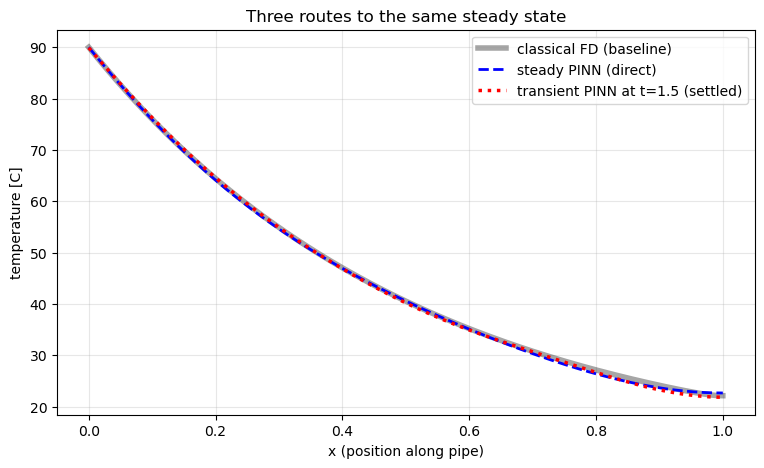

max |steady PINN    - FD| = 0.0097
max |transient@t=T  - FD| = 0.0110
outlet temp  ->  FD 22.1 C | steady PINN 22.7 C | transient PINN 21.8 C


In [7]:
xq = torch.linspace(0, L, 200, device=device).reshape(-1,1)
with torch.no_grad():
    th_steady_pinn = model_s(xq).cpu().numpy().flatten()
    th_transient_T = model(xq, torch.full_like(xq, T)).cpu().numpy().flatten()   # transient at t=T
xq_np = xq.cpu().numpy().flatten()
th_fd = np.interp(xq_np, x_ss, theta_ss)

plt.figure(figsize=(9,5))
plt.plot(x_ss, to_celsius(theta_ss), "k-",  lw=4, alpha=0.35, label="classical FD (baseline)")
plt.plot(xq_np, to_celsius(th_steady_pinn), "b--", lw=2,      label="steady PINN (direct)")
plt.plot(xq_np, to_celsius(th_transient_T), "r:",  lw=2.5,    label=f"transient PINN at t={T} (settled)")
plt.xlabel("x (position along pipe)"); plt.ylabel("temperature [C]")
plt.title("Three routes to the same steady state"); plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"max |steady PINN    - FD| = {np.max(np.abs(th_steady_pinn - th_fd)):.4f}")
print(f"max |transient@t=T  - FD| = {np.max(np.abs(th_transient_T - th_fd)):.4f}")
print(f"outlet temp  ->  FD {to_celsius(th_fd[-1]):.1f} C | steady PINN {to_celsius(th_steady_pinn[-1]):.1f} C | transient PINN {to_celsius(th_transient_T[-1]):.1f} C")

All three curves sit on top of each other. Note the transient PINN is *slightly* less exact at the outlet — it
had to learn a whole 2-D surface $\theta(x,t)$ and we only read off its last time slice, whereas the steady PINN
solved the easier 1-D problem directly. **That is a real lesson: if you only need the steady answer, solve the
steady problem — don't make the network learn a time dimension you are going to throw away.**

### 4c. The operational KPI: delivery temperature over time

The customers live at $x=L$. Here is the temperature they receive as the plant warms the pipe — exactly the
curve an operations dashboard would show. It rises from ground temperature and levels off at the steady
delivery temperature we predicted classically.

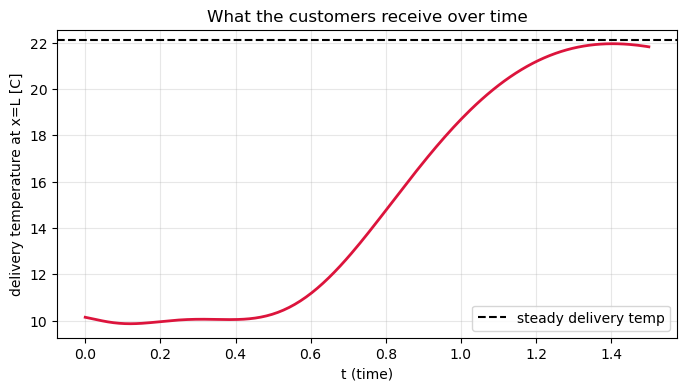

In [8]:
tline = torch.linspace(0, T, 200, device=device).reshape(-1,1)
xL = torch.full_like(tline, L)
with torch.no_grad():
    th_out = model(xL, tline).cpu().numpy().flatten()
plt.figure(figsize=(8,4))
plt.plot(tline.cpu().numpy().flatten(), to_celsius(th_out), lw=2, color="crimson")
plt.axhline(to_celsius(theta_ss[-1]), color="k", ls="--", label="steady delivery temp")
plt.xlabel("t (time)"); plt.ylabel("delivery temperature at x=L [C]")
plt.title("What the customers receive over time"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5. Inverse PINN — monitoring heat loss from a few sensors

Now the money question. The pipe is buried; we cannot see $\beta$. But the operator has installed **4
temperature sensors** along the pipe. Assuming the system runs at steady state (true for a continuously
operating network), can we **infer the heat-loss coefficient $\beta$** — and therefore how much energy is
leaking to the ground?

We reuse **exactly the `SteadyPINN` from section 4b** — same network, same residual, same two boundary
conditions. Only two things change:
- $\beta$ is no longer a known constant but a **trainable parameter**,
- the loss gains a **sensor-mismatch** term.

That is the whole difference between *solving* the pipe and *diagnosing* it: `beta` moves from the known side to
the learned side, and data joins the loss.

There is no initial condition any more — a steady state has no time derivative, so nothing needs to be pinned
down at $t=0$. But we keep **both spatial** boundary conditions, and it is worth being explicit about why.

> **Why keep both BCs when the sensors already constrain the pipe?**
>
> Strictly, you *could* drop the outflow condition $\theta_x(L)=0$ here and still get a good answer: we have a
> sensor at $x=0.9$, right where that condition would act, so the **data already carries the same information**.
> (Try it — comment the `loss_out` term out and the recovered $\beta$ barely moves. This is a genuine and
> important insight: **in an inverse problem, data and boundary conditions are interchangeable sources of
> information**, which is exactly why notebook 04 could drop its initial condition entirely.)
>
> But as a matter of **good practice, impose every condition you actually know.** The equation is **second order
> in $x$** (because of the $\alpha\,\theta_{xx}$ term), so it mathematically admits *two* spatial conditions —
> and we genuinely know both. They cost nothing, they are **free regularisation**, and they make the model
> well-posed rather than relying on the sensor layout to save you. The moment you lose that near-outlet
> sensor, the BC is the only thing holding the far end of the pipe down.

We test it on a **degraded** pipe whose true heat loss has crept up to $\beta_\text{true}=3.2$ (worse
insulation, perhaps water ingress), and see if the twin catches it.

In [9]:
# --- generate sparse noisy sensor data from a DEGRADED pipe (true beta unknown to the model) ---
beta_true = 3.2
x_sens = np.array([0.15, 0.4, 0.65, 0.9])
_, theta_true_full = steady_state_fd(v, alpha, beta_true, N=400)
theta_at_sensors = np.interp(x_sens, np.linspace(0,L,400), theta_true_full)
noise = 0.01
theta_meas = theta_at_sensors + np.random.normal(0, noise, size=x_sens.shape)
print("sensor positions:", x_sens)
print("measured temps [C]:", np.round(to_celsius(theta_meas),1))

# --- inverse PINN: SAME steady network as section 4b, but now beta is trainable ---
model_i  = SteadyPINN(hidden=32, n_hidden_layers=3).to(device)
log_beta = torch.nn.Parameter(torch.tensor(np.log(1.0), dtype=torch.float32, device=device))  # start guess beta=1.0
def get_beta(): return torch.exp(log_beta)

opt_i = torch.optim.Adam(list(model_i.parameters()) + [log_beta], lr=3e-3)

xs_t = torch.tensor(x_sens, dtype=torch.float32, device=device).reshape(-1,1)
ys_t = torch.tensor(theta_meas, dtype=torch.float32, device=device).reshape(-1,1)
xf_i = (torch.rand(1500,1, device=device)*L)
x0_i = torch.zeros(1,1, device=device)               # inlet  x=0
xL_i = torch.ones(1,1, device=device)*L              # outlet x=L

beta_hist = []
for it in range(4000):                    # steady-state inverse: ~1-2 min on CPU
    opt_i.zero_grad()
    th, th_x, th_xx = steady_derivs(model_i, xf_i)
    # identical residual to 4b, except beta is now LEARNED instead of known
    loss_pde  = torch.mean((v*th_x - alpha*th_xx + get_beta()*th)**2)
    loss_data = torch.mean((model_i(xs_t) - ys_t)**2)                 # the sensors
    loss_in   = (model_i(x0_i) - 1.0)**2                              # BC 1: inlet theta(0)=1
    _, thx_L, _ = steady_derivs(model_i, xL_i)
    loss_out  = thx_L**2                                              # BC 2: outflow theta_x(L)=0
    # both spatial BCs kept: the equation is 2nd order in x, and they are free regularisation
    loss = loss_pde + 50.0*loss_data + 20.0*(loss_in.mean() + loss_out.mean())
    loss.backward(); opt_i.step()
    beta_hist.append(get_beta().item())
    if it % 1000 == 0:
        print(f"iter {it:5d} | loss {loss.item():.3e} | beta_est {get_beta().item():.3f} (true {beta_true})")
print(f"\nRecovered heat-loss coefficient beta = {get_beta().item():.3f}  (true {beta_true})")

sensor positions: [0.15 0.4  0.65 0.9 ]
measured temps [C]: [62.3 34.2 22.  17.1]
iter     0 | loss 1.860e+01 | beta_est 0.997 (true 3.2)


iter  1000 | loss 1.027e-02 | beta_est 3.029 (true 3.2)


iter  2000 | loss 6.628e-03 | beta_est 3.058 (true 3.2)


iter  3000 | loss 6.977e-03 | beta_est 3.066 (true 3.2)



Recovered heat-loss coefficient beta = 3.058  (true 3.2)


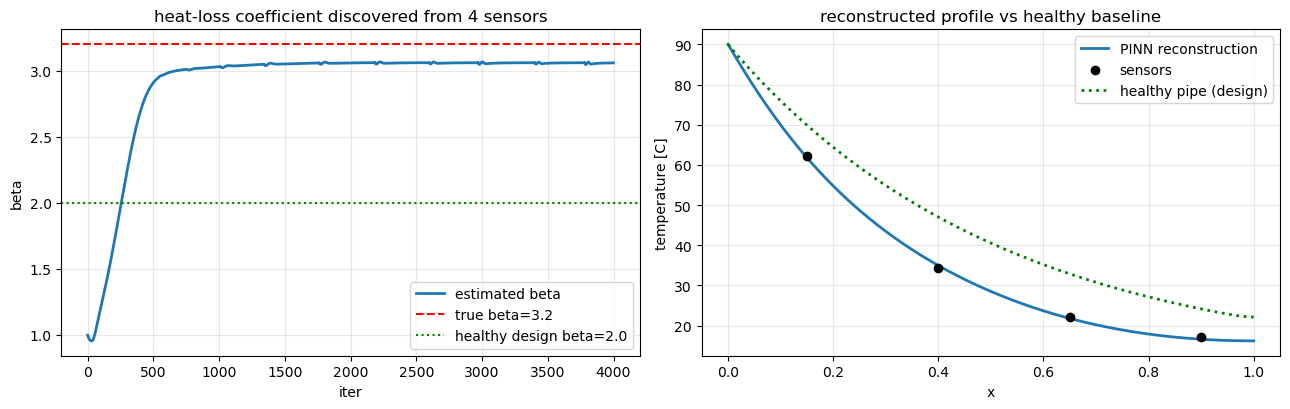

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.2))
ax[0].plot(beta_hist, lw=2, label="estimated beta")
ax[0].axhline(beta_true, color="red", ls="--", label=f"true beta={beta_true}")
ax[0].axhline(beta, color="green", ls=":", label=f"healthy design beta={beta}")
ax[0].set_xlabel("iter"); ax[0].set_ylabel("beta"); ax[0].set_title("heat-loss coefficient discovered from 4 sensors")
ax[0].legend(); ax[0].grid(alpha=0.3)

xg = torch.linspace(0,L,200, device=device).reshape(-1,1)
with torch.no_grad():
    th_fit = model_i(xg).cpu().numpy().flatten()
ax[1].plot(xg.cpu().numpy().flatten(), to_celsius(th_fit), lw=2, label="PINN reconstruction")
ax[1].scatter(x_sens, to_celsius(theta_meas), color="k", zorder=5, label="sensors")
ax[1].plot(x_ss, to_celsius(theta_ss), "g:", lw=2, label="healthy pipe (design)")
ax[1].set_xlabel("x"); ax[1].set_ylabel("temperature [C]"); ax[1].set_title("reconstructed profile vs healthy baseline")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5a. Turn the parameter into a business number

A heat-loss coefficient is abstract; euros are not. The steady heat lost to the ground per unit length is
proportional to $\beta\,(u-u_\text{env})$. We integrate it along the pipe for the **healthy design** $\beta$ and
the **estimated degraded** $\beta$, and report the *extra* loss — the kind of figure that justifies sending a
maintenance crew.

In [11]:
def total_heat_loss(bb):
    x = np.linspace(0, L, 400)
    _, th = steady_state_fd(v, alpha, bb)
    # loss ~ integral of beta*(u - u_env) dx = beta*(T_in-u_env)*integral(theta) dx
    return bb*(T_in-u_env)*np.trapz(th, x)

Q_design   = total_heat_loss(beta)
Q_degraded = total_heat_loss(get_beta().item())
extra = (Q_degraded/Q_design - 1)*100
print(f"heat loss (design, beta={beta})      : {Q_design:8.2f}  [arb. energy units]")
print(f"heat loss (estimated, beta={get_beta().item():.2f}) : {Q_degraded:8.2f}")
print(f"==> the pipe is losing about {extra:.0f}% MORE heat than designed  -> flag for inspection")

heat loss (design, beta=2.0)      :    70.99  [arb. energy units]
heat loss (estimated, beta=3.06) :    79.94
==> the pipe is losing about 13% MORE heat than designed  -> flag for inspection


## 6. When should you actually reach for a PINN? (the judgement slide)

An interviewer will respect you more for knowing the *limits* than the hype. Here is an honest map.

| Situation | Use a PINN? | Why |
|---|---|---|
| Known equation, simple geometry, need speed | ❌ usually not | Classical FD/FE/CFD solvers are faster and battle-tested (see our steady-state baseline). |
| **Unknown parameter(s)** to infer from data | ✅ **yes** | Inverse problems are the PINN sweet spot (notebooks 04 & 05). |
| **Fusing sparse/noisy sensors with physics** | ✅ **yes** | Physics regularises; data-efficient; physically consistent reconstruction. |
| Need a **differentiable surrogate** for optimisation/control | ✅ often | One smooth model you can back-propagate through for design or MPC. |
| Highly **oscillatory / sharp-shock / long-horizon** dynamics | ⚠️ careful | Spectral bias (notebook 02); needs special tricks or may fail. |
| **No physics known**, lots of data | ❌ no | Use ordinary ML / time-series models. |

**The recurring theme:** PINNs shine when you have **trustworthy physics but imperfect data** — precisely the
condition of a real energy asset with a few sensors and expensive-to-model internals.

## 7. Where a real project goes next

- **2D/3D geometry** (pipe cross-sections, heat-exchanger plates, reservoir grids) — same idea, more input dims.
- **Coupled physics** (flow + heat + mechanics), **many parameters**, **fields** of unknown coefficients.
- **Uncertainty quantification**: not just $\beta$, but a confidence interval on it (Bayesian PINNs).
- **Real-time twins**: retrain/fine-tune as new sensor data streams in, alarming when a parameter drifts.
- **Better training**: hard-constraint boundary conditions, adaptive collocation, Fourier features, L-BFGS
  polishing, causal weighting — the toolbox that tames the hard cases from notebook 02.

## 8. Series recap — what you can now explain on a whiteboard

1. **What a PINN is** — a network trained to obey a differential equation via autograd (01).
2. **Higher-order & oscillatory** physics and PINN **spectral bias** (02).
3. **PDEs** in space+time with initial/boundary conditions, visualised as fields (03).
4. **Inverse problems / digital twins** — discovering hidden parameters from sparse noisy sensors (04).
5. **An end-to-end energy business case** — operations forecasting *and* condition monitoring, with an honest
   view of when PINNs beat classical solvers and when they don't (05).

That is a genuinely strong, well-rounded understanding to walk into an energy-company interview with. Good luck!